In [479]:
import pandas as pd

notes = pd.read_csv('~/Downloads/notes-00000.tsv', sep='\t') # data downloaded from X on 11/14/24
status_history = pd.read_csv('~/Downloads/noteStatusHistory-00000.tsv', sep='\t')

notes = notes.astype(str)
status_history = status_history.astype(str)

notesandstatus = notes.merge(status_history, on='noteId', how='outer')

columns_to_keep = [
    "noteId",
    "noteAuthorParticipantId_x",
    "createdAtMillis_x",
    "tweetId",
    "classification",
    "summary",
    "timestampMillisOfFirstNonNMRStatus",
    "firstNonNMRStatus"
    
]

notesandstatus = notesandstatus[columns_to_keep]

/var/folders/z0/qzq8g2qx44lcdrv4wy390xdc0000gs/T/ipykernel_80904/2693047363.py:3: DtypeWarning: Columns (5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  notes = pd.read_csv('~/Downloads/notes-00000.tsv', sep='\t') # data downloaded from X on 11/14/24
/var/folders/z0/qzq8g2qx44lcdrv4wy390xdc0000gs/T/ipykernel_80904/2693047363.py:4: DtypeWarning: Columns (10,19) have mixed types. Specify dtype option on import or set low_memory=False.
  status_history = pd.read_csv('~/Downloads/noteStatusHistory-00000.tsv', sep='\t')


In [313]:
len(notesandstatus)

1566751

In [ ]:
%pip install langdetect

In [483]:
# *this cell takes about 45 minutes to run*

notesandstatus['has_summary'] = notesandstatus['summary'].notna() & notesandstatus['summary'].str.strip().ne("")
notesandstatus['summary'] = notesandstatus['summary'].astype(str)

from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException

DetectorFactory.seed = 0

def is_english(text):
    try:
        return detect(text) == "en"
    except LangDetectException:
        return False 

notesandstatus['is_english'] = notesandstatus['summary'].apply(is_english)

# saving 'notesandstatus.csv' here, so I can read in this basic version of my data w/o needing to rerun spanish filter.
notesandstatus.to_csv('~/community_notes_data/notesandstatus.csv', index=False)

In [491]:
notesandstatus = pd.read_csv('~/community_notes_data/notesandstatus.csv', dtype={'tweetId': str})

df = notesandstatus

keywords = [
    "activist", "amendment", "anti-corruption", "assembly", "autocracy", "authoritarian", 
    "Ballot", "biden", "campaign", "candidate", "capitalist", "caucus", "censorship", 
    "city council", "climate policy", "Clinton", "civic", "civil liberties", "council", 
    "Congress", "Congressman", "congresswoman", "conservative", "constitution", "corruption", 
    "Covid", "debate", "Democrat", "democracy", "diplomacy", "election", "equality", 
    "European Union", "executive", "federal", "foreign", "freedom", "governor", "Hamas", 
    "Harris", "healthcare", "Hezbollah", "House of Representatives", "impeachment", "immigration", 
    "infrastructure", "Iran", "Israel", "judiciary", "justice", "Kim Jong Un", "law", "left-wing", 
    "legislation", "liberal", "lobbyist", "mandate", "mayor", "Mcconnell", "military", "Movement", 
    "MP", "nation", "national security", "nationalism", "NATO", "Netanyahu", "Obama", "PAC", 
    "parliament", "party", "patriot", "patriotism", "Pelosi", "polling", "policy", "poverty", 
    "power", "president", "progressive", "public office", "Putin", "rally", "reform", "regulation", 
    "relations", "representative", "Republican", "rights", "sanctions", "Schumer", "Senate", "senator", 
    "socialism", "socialist", "sovereignty", "state", "stimulus", "Supreme court", "Surveillance", 
    "starmer", "tariffs", "taxes", "transparency", "Trump", "Ukraine", "Vance", "veto", "vote", 
    "Walz", "welfare", "White house", "Xi JinPing", "Zelensky"
]

def find_keywords(text, keywords):
    text_lower = str(text).lower()
    found_keywords = [
        keyword for keyword in keywords 
        if f" {keyword.lower()} " in f" {text_lower} "
    ]
    return found_keywords

found_keywords_list = []

for text in df['summary']:
    found_keywords_list.append(find_keywords(text, keywords))

df['found_keywords'] = found_keywords_list

df['contains_keywords'] = df['found_keywords'].str.len() > 0

political_tweet_ids = set(df[df['contains_keywords']]['tweetId'])

df['isnot_political'] = (df['found_keywords'].str.len() == 0) & (~df['tweetId'].isin(political_tweet_ids))

df['is_political'] = df['contains_keywords'] | (~df['contains_keywords'] & ~df['isnot_political'])

# Defining (for now) "is_followedup" as anything that has a rating other than NMR (at any time), 
# even though new notes can come in and the rating can potentially change within first 2 weeks (need to confirm this!)

import numpy as np

df['firstNonNMRStatus'] = df['firstNonNMRStatus'].replace('nan', np.nan)
df['is_followedup'] = df['firstNonNMRStatus'].notna()

df['got_shown'] = (df['firstNonNMRStatus'] == 'CURRENTLY_RATED_HELPFUL').astype(int)

df['time_difference'] = None

df['timestampMillisOfFirstNonNMRStatus'] = df['timestampMillisOfFirstNonNMRStatus'].replace('nan', np.nan)

df['timestampMillisOfFirstNonNMRStatus'] = df['timestampMillisOfFirstNonNMRStatus'].astype(float).astype('Int64')

df['createdAtMillis_x'] = df['createdAtMillis_x'].replace('nan', np.nan)

df['createdAtMillis_x'] = df['createdAtMillis_x'].astype(float).astype('Int64')

for index, row in df.iterrows():
    if row['got_shown'] == 1:
        df.at[index, 'time_difference'] = row['timestampMillisOfFirstNonNMRStatus'] - row['createdAtMillis_x']

df['hours_to_show'] = df['time_difference'] / (1000 * 60 * 60)

df_english = df[df['is_english'] == True]

/var/folders/z0/qzq8g2qx44lcdrv4wy390xdc0000gs/T/ipykernel_80904/3050669132.py:1: DtypeWarning: Columns (1,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  notesandstatus = pd.read_csv('~/community_notes_data/notesandstatus.csv', dtype={'tweetId': str})


In [493]:
df_100 = df.head(100)
df_100.to_csv('df_100.csv', index=False)

In [333]:
# do english vs non-english notes get followed up or approved at different rates? what are they?
# using firstNonNMRStatus column (containing either CRH or CRNH) as proxy for getting followed up on. 
# Not perfect proxy - notes will occassionally get pushed back to NMR if contradictory ratings are submitted)
df.groupby('is_english').is_followedup.sum()

is_english
False    122084
True     147588
Name: is_followedup, dtype: int64

In [335]:
df.groupby('is_english').is_followedup.mean()

is_english
False    0.185970
True     0.162135
Name: is_followedup, dtype: float64

In [337]:
df.groupby('is_english').got_shown.mean()

is_english
False    0.117194
True     0.106561
Name: got_shown, dtype: float64

In [ ]:
# Next, manually checking to see if this process accurately groups the political and nonpolitical

In [173]:
## are the results of this documented in my project notes?
# randomize df and manually check actual tweets for accuracy (are they political?)
df_rand = df.sample(frac=1).reset_index(drop=True)
df_rand_100 = df_rand.head(100)
df_rand_100.to_csv("df_rand_100.csv", index=False)

In [349]:
# got shown rate at the noteId level (less meaningful)
df_english.groupby('is_political').got_shown.mean()

is_political
False    0.121918
True     0.077671
Name: got_shown, dtype: float64

In [293]:
# Aggregate at the tweetId level (and english-only)

df_english = df[df['is_english'] == True]
tweet_level = df_english.groupby('tweetId').agg(
    is_political=('is_political', 'first'),  
    got_shown=('got_shown', 'max') 
)

result = tweet_level.groupby('is_political')['got_shown'].mean()
print(result)


is_political
False    0.165265
True     0.130427
Name: got_shown, dtype: float64


In [345]:
# NoteId level:
# Calculate average hours for is_political Notes and isnot_political Notes:
df_english.groupby('is_political').time_difference.mean() / (1000 * 60 * 60)

is_political
False    35.618563
True     46.915575
Name: time_difference, dtype: object

In [357]:
# tweetId level
tweet_level = df_english.groupby('tweetId').agg(
    is_political=('is_political', 'first'),  
    time_difference=('time_difference', 'min') 
)
tweet_level.groupby('is_political').time_difference.mean() / (1000 * 60 * 60)

is_political
False    36.036286
True     44.136115
Name: time_difference, dtype: object

In [131]:
# noteId level:
df_english.groupby('is_political').time_difference.median() / (1000 * 60 * 60)

is_political
False    6.928513
True     6.614029
Name: time_difference, dtype: object

In [499]:
# tweetId level
tweet_level = df_english.groupby('tweetId').agg(
    is_political=('is_political', 'first'),  
    time_difference=('time_difference', 'min') 
)
tweet_level.groupby('is_political').time_difference.median() / (1000 * 60 * 60)

is_political
False    6.946783
True     6.358337
Name: time_difference, dtype: object

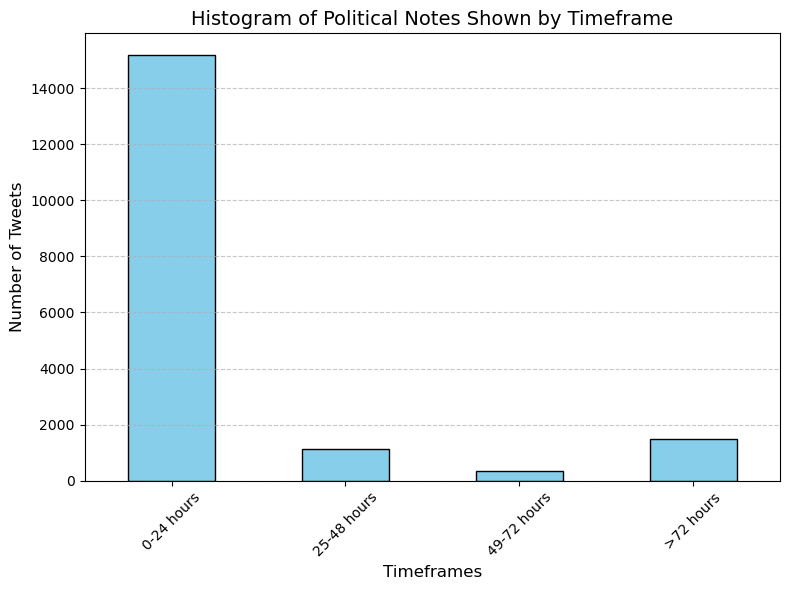

In [383]:
# Histogram of timeframes to get approved/posted:
import pandas as pd
import matplotlib.pyplot as plt

# Filter for political notes that got shown
df_english = df[df['is_english'] == True]
tweet_level = df_english.groupby('tweetId').agg(
    is_political=('is_political', 'first'),  
    got_shown=('got_shown', 'max'),
    hours_to_show=('hours_to_show', 'min')
)
filtered = tweet_level[(tweet_level['is_political'] == True) & (tweet_level['got_shown'] == 1)].copy()

# Create bins for timeframes
bins = [0, 24, 48, 72, float('inf')]  # Define bin edges
labels = ['0-24 hours', '25-48 hours', '49-72 hours', '>72 hours']  # Bin labels
filtered.loc[:, 'timeframe'] = pd.cut(filtered['hours_to_show'], bins=bins, labels=labels)

# Count notes in each timeframe
timeframe_counts = filtered['timeframe'].value_counts().sort_index()

# Plot histogram
plt.figure(figsize=(8, 6))
timeframe_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Histogram of Political Notes Shown by Timeframe', fontsize=14)
plt.xlabel('Timeframes', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

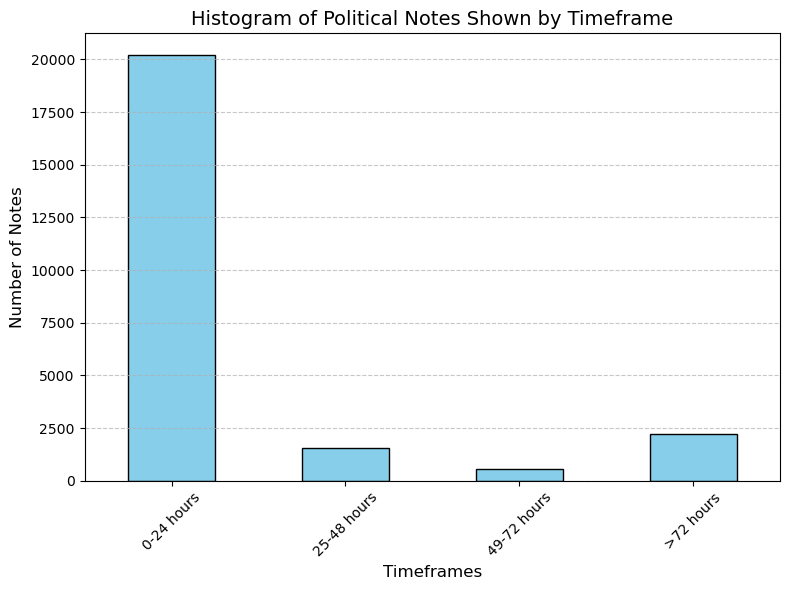

In [381]:
# Histogram of timeframes to get approved/posted:
import pandas as pd
import matplotlib.pyplot as plt

# Filter for political notes that got shown
df_english = df[df['is_english'] == True]

filtered = df_english[(df_english['is_political'] == True) & (df_english['got_shown'] == 1)].copy()

# Create bins for timeframes
bins = [0, 24, 48, 72, float('inf')]  # Define bin edges
labels = ['0-24 hours', '25-48 hours', '49-72 hours', '>72 hours']  # Bin labels
filtered.loc[:, 'timeframe'] = pd.cut(filtered['hours_to_show'], bins=bins, labels=labels)

# Count notes in each timeframe
timeframe_counts = filtered['timeframe'].value_counts().sort_index()

# Plot histogram
plt.figure(figsize=(8, 6))
timeframe_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Histogram of Political Notes Shown by Timeframe', fontsize=14)
plt.xlabel('Timeframes', fontsize=12)
plt.ylabel('Number of Notes', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [497]:
# random sample of 10 political tweets that get warnings and 10 that didn't get warnings: 
# gauge if there are patterns and worth looking further into:
pol_warnings_rand = df_english[(df_english['is_political'] == True) & (df_english['got_shown'] == 1)].sample(frac=1, random_state=42)
pol_warnings_rand = pol_warnings_rand.head(10)
pol_warnings_rand.to_csv('pol_warnings_rand.csv', index=False)

pol_nowarnings_rand = df_english[(df_english['is_political'] == True) & (df_english['got_shown'] == 0)].sample(frac=1, random_state=42)
pol_nowarnings_rand = pol_nowarnings_rand.head(10)
pol_nowarnings_rand.to_csv('pol_nowarnings_rand.csv', index=False)

In [503]:
# random sample of tweets for whom 1+ notes have been submitted (this is the entire corpus)
# What % are not true? How does this correspond to % got_shown?
tweets_rand = df_english.sample(frac=1, random_state=33)
tweets_rand = tweets_rand.head(25)
tweets_rand.to_csv('tweets_rand.csv', index=False)

In [ ]:
# Preprocessing: Cells to Skip for Now - see below:

In [ ]:
# Use to move columns around as needed

columns = df.columns.tolist()  
is_political_index = columns.index('is_political')  

new_position = max(0, is_political_index - 2)

columns.insert(new_position, columns.pop(is_political_index))
df = df[columns]

In [ ]:
# read in each notes_ratings file

import pandas as pd

notes_ratings0 = pd.read_csv('~/Downloads/ratings-00000.tsv', sep='\t')
notes_ratings1 = pd.read_csv('~/Downloads/ratings-00001.tsv', sep='\t')
notes_ratings2 = pd.read_csv('~/Downloads/ratings-00002.tsv', sep='\t')
notes_ratings3 = pd.read_csv('~/Downloads/ratings-00003.tsv', sep='\t')
notes_ratings4 = pd.read_csv('~/Downloads/ratings-00004.tsv', sep='\t')
notes_ratings5 = pd.read_csv('~/Downloads/ratings-00005.tsv', sep='\t')
notes_ratings6 = pd.read_csv('~/Downloads/ratings-00006.tsv', sep='\t')
notes_ratings7 = pd.read_csv('~/Downloads/ratings-00007.tsv', sep='\t')
notes_ratings8 = pd.read_csv('~/Downloads/ratings-00008.tsv', sep='\t')
notes_ratings9 = pd.read_csv('~/Downloads/ratings-00009.tsv', sep='\t')
notes_ratings10 = pd.read_csv('~/Downloads/ratings-00010.tsv', sep='\t')
notes_ratings11 = pd.read_csv('~/Downloads/ratings-00011.tsv', sep='\t')
notes_ratings12 = pd.read_csv('~/Downloads/ratings-00012.tsv', sep='\t')
notes_ratings13 = pd.read_csv('~/Downloads/ratings-00013.tsv', sep='\t')
notes_ratings14 = pd.read_csv('~/Downloads/ratings-00014.tsv', sep='\t')
notes_ratings15 = pd.read_csv('~/Downloads/ratings-00015.tsv', sep='\t')

In [ ]:
# This didn't work - still too big for my RAM
# Loop through the notes_ratings one at a time; later once I know which notes ratings I want to look at and use.
# pre-process to make smaller (remove columns not needed); merge into single csv
notes_ratings_list = [notes_ratings0, notes_ratings1, notes_ratings2, notes_ratings3, notes_ratings4, notes_ratings5, notes_ratings6, notes_ratings7, notes_ratings8, notes_ratings9, notes_ratings10, notes_ratings11, notes_ratings12, notes_ratings13, notes_ratings14, notes_ratings15]

# dropping columns from Notes_Ratings I don't need
# Initialize an empty dictionary to store the processed DataFrames
processed_files = {}

# Loop through the files and process them
for i, file in enumerate(notes_ratings_list):
    # Define columns to drop
    columns = "helpful, notHelpful, helpfulInformative, helpfulEmpathetic, helpfulUniqueContext, notHelpfulOpinionSpeculationOrBias, notHelpfulOutdated, notHelpfulOffTopic"
    quoted_columns = [col.strip() for col in columns.split(",")]
    
    # Process the file
    notes_ratings_clean = file.drop(columns=quoted_columns, errors='ignore')
    notes_ratings_clean = notes_ratings_clean.astype(str)
    
    # Save the processed DataFrame in the dictionary with a unique key
    processed_files[f'file_{i}'] = notes_ratings_clean

In [ ]:
# skip for now
# read in userEnrollment file when/if needed
import pandas as pd

enrollment = pd.read_csv('~/Downloads/userEnrollment-00000.tsv', sep='\t')

In [ ]:
### Old bits of code:

In [ ]:
## Old code using a regular expression...but Field encouraged me to change to a simpler substring search (which I did above)
# Check for keywords in "summary" column (text of Notes) using a regexp

import re

# ensure all objects in summary column are strings
df['summary'] = df['summary'].astype(str)

# uses a regular expression to search for each keyword in the "summary" text
def find_keywords(text, keywords):
    found_keywords = [
        keyword for keyword in keywords 
        if re.search(rf'\b{re.escape(keyword)}\b', str(text), re.IGNORECASE)
    ]
    return found_keywords